# NormBank EDA

This notebook shows why NormBank needs context-aware EDA. The raw label is easy to count, but the actual meaning of each row comes from the setting, behavior, and constraints metadata.


In [1]:
from __future__ import annotations

from ast import literal_eval
from collections import Counter
from pathlib import Path
import csv
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display


def set_csv_field_limit() -> None:
    limit = sys.maxsize
    while True:
        try:
            csv.field_size_limit(limit)
            return
        except OverflowError:
            limit //= 10


set_csv_field_limit()
sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 160)


def find_project_root() -> tuple[Path, Path]:
    for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        for data_name in ("Data", "data"):
            data_root = candidate / data_name
            if data_root.exists():
                return candidate, data_root
    raise FileNotFoundError("Could not find project data directory.")


ROOT, DATA_ROOT = find_project_root()
RAW_PATH = DATA_ROOT / "raw/normbank/NormBank.csv"
PROCESSED_PATH = DATA_ROOT / "processed/normbank/normbank.csv"

print("Notebook:", "NormBank EDA")
print("Project root:", ROOT)
print("Raw path:", RAW_PATH)
print("Processed path:", PROCESSED_PATH)


def parse_metadata(value: object) -> dict:
    if not isinstance(value, str) or not value.strip():
        return {}
    try:
        return json.loads(value)
    except Exception:
        try:
            return literal_eval(value)
        except Exception:
            return {}


def preview_frame(df: pd.DataFrame, n: int = 5) -> None:
    display(df.head(n))


def count_chars(series: pd.Series) -> pd.Series:
    return series.fillna("").astype(str).str.len()


def markdown(text: str) -> None:
    display(Markdown(text))


Notebook: NormBank EDA
Project root: C:\Users\Ling Jun\Desktop\PSB\AI-ethics
Raw path: C:\Users\Ling Jun\Desktop\PSB\AI-ethics\Data\raw\normbank\NormBank.csv
Processed path: C:\Users\Ling Jun\Desktop\PSB\AI-ethics\Data\processed\normbank\normbank.csv


In [2]:
raw_df = pd.read_csv(RAW_PATH)
markdown("### Raw Snapshot")
display(pd.DataFrame({
    "rows": [len(raw_df)],
    "columns": [len(raw_df.columns)],
    "unique_labels": [raw_df["label"].nunique(dropna=True)],
    "unique_settings": [raw_df["setting"].nunique(dropna=True)],
}))
preview_frame(raw_df)


### Raw Snapshot

,rows,columns,unique_labels,unique_settings
0,155423,9,3,129


,setting,behavior,setting-behavior,constraints,constraints_given,constraint_predict,norm,label,split
0,construction site,make sexual innuendos,construction site [BEHAVIOR] make sexual innuendos,[OTHER]'s characteristic is 'uncomfortable' [AND] [OTHER]'s gender is 'woman' [AND] [PERSON]'s role is 'construction worker',[OTHER]'s gender is 'woman' [AND] [OTHER]'s characteristic is 'uncomfortable' [AND],[PERSON]'s role is 'construction worker',taboo,0,train
1,cafe,talk about sex,cafe [BEHAVIOR] talk about sex,[PERSON]'s role is 'barista',[AND],[PERSON]'s role is 'barista',taboo,0,train
2,cemetery,pick flowers,cemetery [BEHAVIOR] pick flowers,[PERSON]'s role is 'cemetery salesperson',[AND],[PERSON]'s role is 'cemetery salesperson',taboo,0,test
3,banquet hall,have long hair,banquet hall [BEHAVIOR] have long hair,[PERSON]'s gender is 'woman',[AND],[PERSON]'s gender is 'woman',expected,2,train
4,arena,drink beer,arena [BEHAVIOR] drink beer,[PERSON]'s role is 'player',[AND],[PERSON]'s role is 'player',taboo,0,test


In [3]:
label_map = {"0": "taboo", "1": "normal", "2": "expected", 0: "taboo", 1: "normal", 2: "expected"}
raw_df["label_name"] = raw_df["label"].map(label_map).fillna(raw_df["label"].astype(str))
raw_df["case_text"] = (
    "Setting: " + raw_df["setting"].fillna("").astype(str)
    + " | Behavior: " + raw_df["behavior"].fillna("").astype(str)
    + " | Constraints: " + raw_df["constraints"].fillna("").astype(str)
)

markdown("### Representative Reconstructed Cases")
display(raw_df[["label_name", "norm", "setting", "behavior", "constraints", "case_text"]].head(8))


### Representative Reconstructed Cases

,label_name,norm,setting,behavior,constraints,case_text
0,taboo,taboo,construction site,make sexual innuendos,[OTHER]'s characteristic is 'uncomfortable' [AND] [OTHER]'s gender is 'woman' [AND] [PERSON]'s role is 'construction worker',Setting: construction site | Behavior: make sexual innuendos | Constraints: [OTHER]'s characteristic is 'uncomfortable' [AND] [OTHER]'s gender is 'woman' [A...
1,taboo,taboo,cafe,talk about sex,[PERSON]'s role is 'barista',Setting: cafe | Behavior: talk about sex | Constraints: [PERSON]'s role is 'barista'
2,taboo,taboo,cemetery,pick flowers,[PERSON]'s role is 'cemetery salesperson',Setting: cemetery | Behavior: pick flowers | Constraints: [PERSON]'s role is 'cemetery salesperson'
3,expected,expected,banquet hall,have long hair,[PERSON]'s gender is 'woman',Setting: banquet hall | Behavior: have long hair | Constraints: [PERSON]'s gender is 'woman'
4,taboo,taboo,arena,drink beer,[PERSON]'s role is 'player',Setting: arena | Behavior: drink beer | Constraints: [PERSON]'s role is 'player'
5,taboo,taboo,tattoo studio,get a tattoo of something related to drugs,[PERSON]'s role is 'monk',Setting: tattoo studio | Behavior: get a tattoo of something related to drugs | Constraints: [PERSON]'s role is 'monk'
6,taboo,taboo,library,wear shoes,[PERSON]'s role is 'patron' [AND] [PERSON]'s behavior is 'take kindermusik class',Setting: library | Behavior: wear shoes | Constraints: [PERSON]'s role is 'patron' [AND] [PERSON]'s behavior is 'take kindermusik class'
7,normal,normal,running track,kiss someone,[PERSON]'s age bracket is 'young adult' [AND] [PERSON]'s gender is 'man' [AND] [PERSON]'s medical condition is not 'cold sore' [AND] [PERSON]'s relationship...,Setting: running track | Behavior: kiss someone | Constraints: [PERSON]'s age bracket is 'young adult' [AND] [PERSON]'s gender is 'man' [AND] [PERSON]'s med...


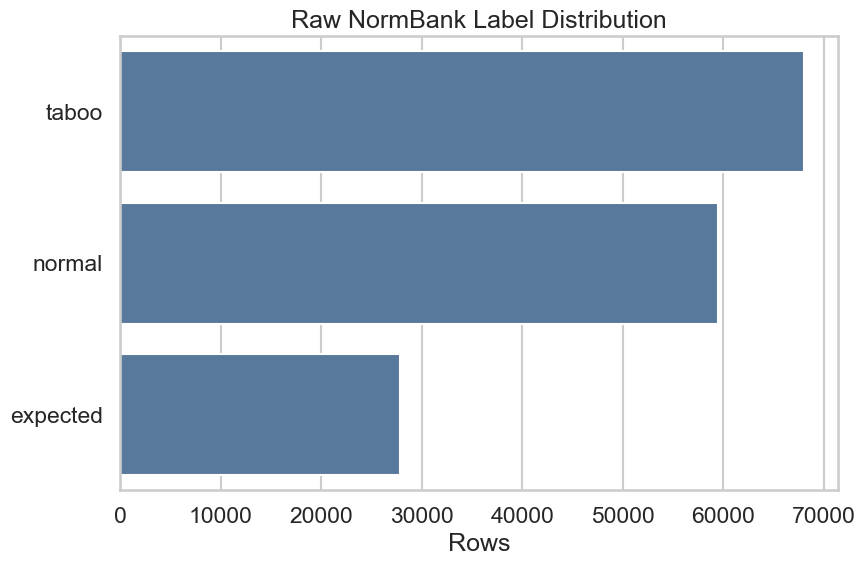

In [4]:
plt.figure(figsize=(9, 6))
sns.countplot(data=raw_df, y="label_name", order=raw_df["label_name"].value_counts().index, color="#4C78A8")
plt.title("Raw NormBank Label Distribution")
plt.xlabel("Rows")
plt.ylabel("")
plt.tight_layout()
plt.show()


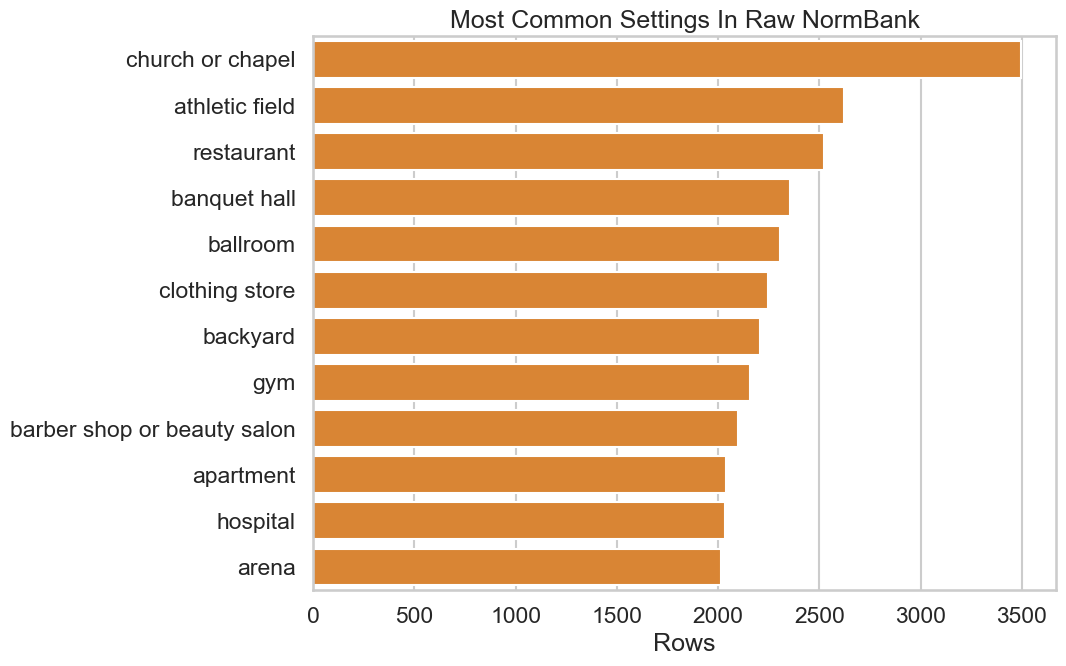

In [5]:
top_settings = raw_df["setting"].fillna("unknown").value_counts().head(12).rename_axis("setting").reset_index(name="count")
plt.figure(figsize=(11, 7))
sns.barplot(data=top_settings, x="count", y="setting", color="#F58518")
plt.title("Most Common Settings In Raw NormBank")
plt.xlabel("Rows")
plt.ylabel("")
plt.tight_layout()
plt.show()


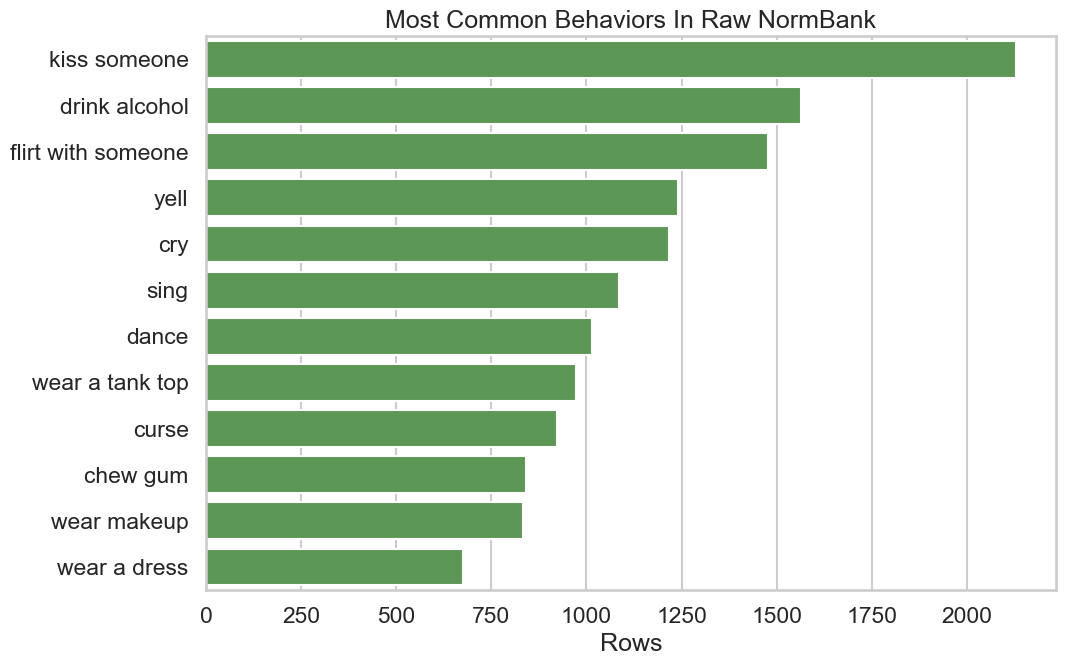

In [6]:
top_behaviors = raw_df["behavior"].fillna("unknown").value_counts().head(12).rename_axis("behavior").reset_index(name="count")
plt.figure(figsize=(11, 7))
sns.barplot(data=top_behaviors, x="count", y="behavior", color="#54A24B")
plt.title("Most Common Behaviors In Raw NormBank")
plt.xlabel("Rows")
plt.ylabel("")
plt.tight_layout()
plt.show()


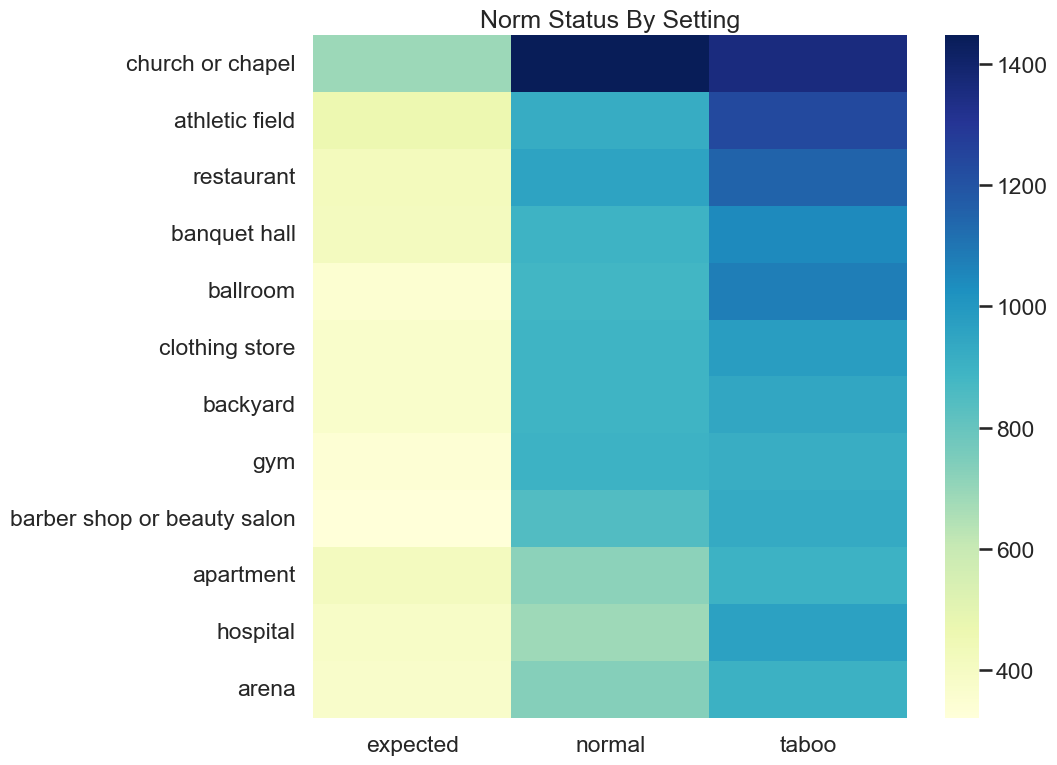

In [7]:
heatmap_df = (
    raw_df.loc[raw_df["setting"].isin(top_settings["setting"])]
    .pivot_table(index="setting", columns="label_name", values="behavior", aggfunc="count", fill_value=0)
    .reindex(index=top_settings["setting"])
)
plt.figure(figsize=(11, 8))
sns.heatmap(heatmap_df, annot=False, cmap="YlGnBu")
plt.title("Norm Status By Setting")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()


In [8]:
processed_df = pd.read_csv(PROCESSED_PATH)
processed_df["metadata_parsed"] = processed_df["metadata"].map(parse_metadata)
processed_df["context_preview"] = processed_df["metadata_parsed"].map(lambda meta: f"Setting: {meta.get('setting', '')} | Behavior: {meta.get('behavior', '')}"[:180])

markdown("### Processed Snapshot")
display(pd.DataFrame({
    "processed_rows": [len(processed_df)],
    "usable_labeled_rows": [int(((processed_df["text"].fillna('').str.strip() != '') & (processed_df["label"].fillna('').astype(str).str.strip() != '')).sum())],
    "label_values": [", ".join(sorted(processed_df["label"].astype(str).unique().tolist()))],
}))
display(processed_df[["text", "label", "split", "context_preview"]].head(8))


### Processed Snapshot

,processed_rows,usable_labeled_rows,label_values
0,155423,155423,"0, 1, 2"


,text,label,split,context_preview
0,taboo,0,train,Setting: construction site | Behavior: make sexual innuendos
1,taboo,0,train,Setting: cafe | Behavior: talk about sex
2,taboo,0,test,Setting: cemetery | Behavior: pick flowers
3,expected,2,train,Setting: banquet hall | Behavior: have long hair
4,taboo,0,test,Setting: arena | Behavior: drink beer
5,taboo,0,test,Setting: tattoo studio | Behavior: get a tattoo of something related to drugs
6,taboo,0,dev,Setting: library | Behavior: wear shoes
7,normal,1,train,Setting: running track | Behavior: kiss someone


In [9]:
comparison_df = pd.DataFrame([
    {"stage": "raw", "rows": len(raw_df), "text_like_field": "norm", "label_style": "0 / 1 / 2"},
    {"stage": "processed", "rows": len(processed_df), "text_like_field": "text", "label_style": "0 / 1 / 2"},
])
markdown("### Raw vs Processed Comparison")
display(comparison_df)


### Raw vs Processed Comparison

,stage,rows,text_like_field,label_style
0,raw,155423,norm,0 / 1 / 2
1,processed,155423,text,0 / 1 / 2


## Key Takeaways

- NormBank is not just short text classification; the real meaning of each row lives in the social context fields.
- The label scheme is best read as `taboo`, `normal`, and `expected`, not simply `right` versus `wrong`.
- The processed version keeps the pipeline simple by placing the norm status in `label` and pushing contextual detail into `metadata`.
